# Task 2 — Training Notebook

This is your main training and experimentation notebook.

**Purpose:**
- Train models with different hyperparameters
- Run cross-validation
- Save model checkpoints
- Track learning curves and validation metrics
- Experiment with data augmentation, LR schedules, architectures, etc.

**Output:**
- Models saved to `generated_data/current_results/`
- Training metrics and plots
- Best model checkpoints

**Runtime:** 10-40 minutes per full training run (expected)


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, train_test_split
from torch.utils.data import DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR, OneCycleLR
from torch import amp
from tqdm import tqdm
import importlib
import os
import json
from datetime import datetime

import models
importlib.reload(models)
from models import create_efficientnet_b0, create_efficientnet_b3
import datasets
importlib.reload(datasets)
from datasets import Task2TrainingDataset300, Task2TestDataset300

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Create directories if they don't exist
os.makedirs("generated_data/current_results", exist_ok=True)
os.makedirs("generated_data/models_experimented", exist_ok=True)
os.makedirs("generated_data/past_submissions", exist_ok=True)


Device: cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti


## Configuration

Modify these hyperparameters to experiment:


In [ ]:
# ============================================================
# HYPERPARAMETERS - Modify these for experiments
# ============================================================

# Training config - Matching 97% submission config
num_epochs = 10  # Matching 97% submission
batch_size = 64  # Matching 97% submission (B3 needs smaller batch)
val_frequency = 1  # Validate every epoch (matching experiment notebook)

# Optimizer config - Matching 97% submission
learning_rate = 0.001  # Matching 97% submission
weight_decay = 0.0001  # Matching 97% submission
optimizer_type = "Adam"  # Options: "Adam", "AdamW", "SGD"

# Scheduler config
scheduler_type = "CosineAnnealing"  # Options: "CosineAnnealing", "StepLR", "OneCycleLR"
scheduler_params = {"T_max": num_epochs}  # For CosineAnnealing

# Loss config
label_smoothing = 0.05

# Data config
use_cross_validation = False  # Set to True for 5-fold CV, False for single train/val split
cv_folds = 5
val_split = 0.2  # Used when use_cross_validation = False
skip_validation = False  # Set to True to skip validation checks and go directly to final model training

# Model config - Matching 97% submission
model_name = "efficientnet_b3"  # EfficientNet-B3 with 300x300 resolution (matching 97% submission)
image_size = 300  # Updated for EfficientNet-B3

# Mixed precision
use_amp = True  # Automatic Mixed Precision

# DataLoader config
num_workers = 4
pin_memory = True
persistent_workers = True
prefetch_factor = 2

print("Configuration loaded!")


Configuration loaded!


## Load Dataset


In [18]:
train_dataset = Task2TrainingDataset300()
val_dataset = Task2TestDataset300()  # No augmentation for validation

n_samples = len(train_dataset)
all_indices = np.arange(n_samples)

print(f"Total training samples: {n_samples}")
print(f"Dataset classes: 10")


Total training samples: 10000
Dataset classes: 10


## Training Functions


In [19]:
def create_optimizer(model, lr, wd, opt_type):
    """Create optimizer based on type."""
    if opt_type == "Adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif opt_type == "AdamW":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    elif opt_type == "SGD":
        return torch.optim.SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer type: {opt_type}")

def create_scheduler(optimizer, sched_type, params):
    """Create learning rate scheduler."""
    if sched_type == "CosineAnnealing":
        return CosineAnnealingLR(optimizer, T_max=params.get("T_max", num_epochs))
    elif sched_type == "StepLR":
        step_size = params.get("step_size", 20)
        gamma = params.get("gamma", 0.1)
        return StepLR(optimizer, step_size=step_size, gamma=gamma)
    elif sched_type == "OneCycleLR":
        max_lr = params.get("max_lr", learning_rate)
        return OneCycleLR(optimizer, max_lr=max_lr, epochs=num_epochs, steps_per_epoch=params.get("steps_per_epoch", 100))
    else:
        return None

def train_one_epoch(model, train_loader, criterion, optimizer, scheduler, scaler, use_amp, device):
    """Train for one epoch - optimized version."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    num_batches = len(train_loader)
    is_onecycle = isinstance(scheduler, OneCycleLR)
    
    print(f"[DEBUG train_one_epoch] Starting epoch. Total batches: {num_batches}")
    
    for step, (inputs, targets) in enumerate(train_loader):
        if step == 0:
            print(f"[DEBUG train_one_epoch] Loading first batch...")
        elif step % 10 == 0:
            print(f"[DEBUG train_one_epoch] Processing batch {step}/{num_batches}...")
        
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        inputs = inputs.to(memory_format=torch.channels_last)
        
        if step == 0:
            print(f"[DEBUG train_one_epoch] First batch loaded to device. Shape: {inputs.shape}")
        
        optimizer.zero_grad(set_to_none=True)
        
        if use_amp:
            with amp.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        
        if step == 0:
            print(f"[DEBUG train_one_epoch] First batch forward/backward completed. Loss: {loss.item():.4f}")
        
        # Compute accuracy
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
        if scheduler is not None and is_onecycle:
            scheduler.step()
        
        running_loss += loss.detach().item()
    
    if scheduler is not None and not is_onecycle:
        scheduler.step()
    
    avg_loss = running_loss / num_batches
    accuracy = correct / total
    print(f"[DEBUG train_one_epoch] Epoch completed. Average loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")
    return avg_loss, accuracy

def validate(model, val_loader, device):
    """Validate model - optimized version."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            x = x.to(memory_format=torch.channels_last)
            
            with amp.autocast(device_type="cuda", dtype=torch.float16):
                pred = model(x)
            _, cls = pred.max(1)
            total += y.size(0)
            correct += (cls == y).sum().item()
    
    return correct / total

print("Training functions defined!")


Training functions defined!


## Training Loop (Single Train/Val Split or Cross-Validation)


In [ ]:
# Initialize tracking
train_losses = []
val_accuracies = []
fold_results = []
best_validation_state = None  # Will store best model state from validation
best_overall_acc = 0.0  # Track best accuracy across all folds

# Skip validation if flag is set
if skip_validation:
    print("Skipping validation - going directly to final model training...\n")
    splits = []  # Empty splits to skip validation loop
else:
    if use_cross_validation:
        print(f"Starting {cv_folds}-fold cross-validation...\n")
        kfold = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
        splits = list(kfold.split(all_indices))
    else:
        print("Using single train/val split...\n")
        train_idx, val_idx = train_test_split(all_indices, test_size=val_split, random_state=42, shuffle=True)
        splits = [(train_idx, val_idx)]

for fold, (train_idx, val_idx) in enumerate(splits):
    fold_name = f"Fold {fold+1}" if use_cross_validation else "Train/Val Split"
    print(f"\n{'='*60}")
    print(f"{fold_name}")
    print(f"{'='*60}\n")
    
    # Create subsets
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(val_dataset, val_idx)
    
    # Create data loaders
    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
        prefetch_factor=prefetch_factor
    )
    
    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
        prefetch_factor=prefetch_factor
    )
    
    # Create model
    if model_name == "efficientnet_b0":
        model = create_efficientnet_b0(num_classes=10).to(device)
        model = model.to(memory_format=torch.channels_last)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    # Create optimizer
    optimizer = create_optimizer(model, learning_rate, weight_decay, optimizer_type)
    
    # Update scheduler_params for OneCycleLR if needed
    if scheduler_type == "OneCycleLR":
        scheduler_params = scheduler_params.copy()
        scheduler_params["steps_per_epoch"] = len(train_loader)
    
    # Create scheduler
    scheduler = create_scheduler(optimizer, scheduler_type, scheduler_params)
    
    # Loss and scaler
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    scaler = amp.GradScaler("cuda") if use_amp else None
    
    # Training loop
    best_acc = 0.0
    fold_train_losses = []
    fold_val_accs = []
    best_model_state = None
    
    for epoch in range(num_epochs):
        # Train
        avg_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, scaler, use_amp, device)
        fold_train_losses.append(avg_loss)
        
        # Validate (skip if skip_validation is True)
        if not skip_validation and ((epoch + 1) % val_frequency == 0 or epoch + 1 == num_epochs):
            acc = validate(model, val_loader, device)
            fold_val_accs.append(acc)
            
            # Save best model state
            if acc > best_acc:
                best_acc = acc
                best_model_state = model.state_dict().copy()
            else:
                best_acc = max(best_acc, acc)
            
            print(f"Epoch {epoch+1}/{num_epochs} | Loss={avg_loss:.4f} | Val Acc={acc:.4f} | Best={best_acc:.4f}")
        elif skip_validation:
            print(f"Epoch {epoch+1}/{num_epochs} | Loss={avg_loss:.4f}")
    
    # Store results
    fold_results.append(best_acc)
    train_losses.append(fold_train_losses)
    val_accuracies.append(fold_val_accs)
    
    # Track best model state across all folds
    if best_acc > best_overall_acc:
        best_overall_acc = best_acc
        if best_model_state is not None:
            best_validation_state = best_model_state.copy()
    
    print(f"\n{fold_name} Best Accuracy: {best_acc:.4f}")

# Print summary
if not skip_validation:
    print(f"\n{'='*60}")
    print("Training Summary")
    print(f"{'='*60}")
    if use_cross_validation:
        print(f"Fold results: {fold_results}")
        print(f"Mean accuracy: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")
    else:
        if len(fold_results) > 0:
            print(f"Best validation accuracy: {fold_results[0]:.4f}")
else:
    print(f"\n{'='*60}")
    print("Skipped validation - proceeding to final model training")
    print(f"{'='*60}")


Using single train/val split...


Train/Val Split

[DEBUG train_one_epoch] Starting epoch. Total batches: 63
[DEBUG train_one_epoch] Loading first batch...
[DEBUG train_one_epoch] First batch loaded to device. Shape: torch.Size([128, 3, 300, 300])
[DEBUG train_one_epoch] First batch forward/backward completed. Loss: 2.3241
[DEBUG train_one_epoch] Processing batch 10/63...
[DEBUG train_one_epoch] Processing batch 20/63...
[DEBUG train_one_epoch] Processing batch 30/63...
[DEBUG train_one_epoch] Processing batch 40/63...
[DEBUG train_one_epoch] Processing batch 50/63...
[DEBUG train_one_epoch] Processing batch 60/63...
[DEBUG train_one_epoch] Epoch completed. Average loss: 1.0362, Accuracy: 0.7079
Epoch 1/20 | Loss=1.0362 | Val Acc=0.8250 | Best=0.8250
[DEBUG train_one_epoch] Starting epoch. Total batches: 63
[DEBUG train_one_epoch] Loading first batch...
[DEBUG train_one_epoch] First batch loaded to device. Shape: torch.Size([128, 3, 300, 300])
[DEBUG train_one_epoch] First batch forwar

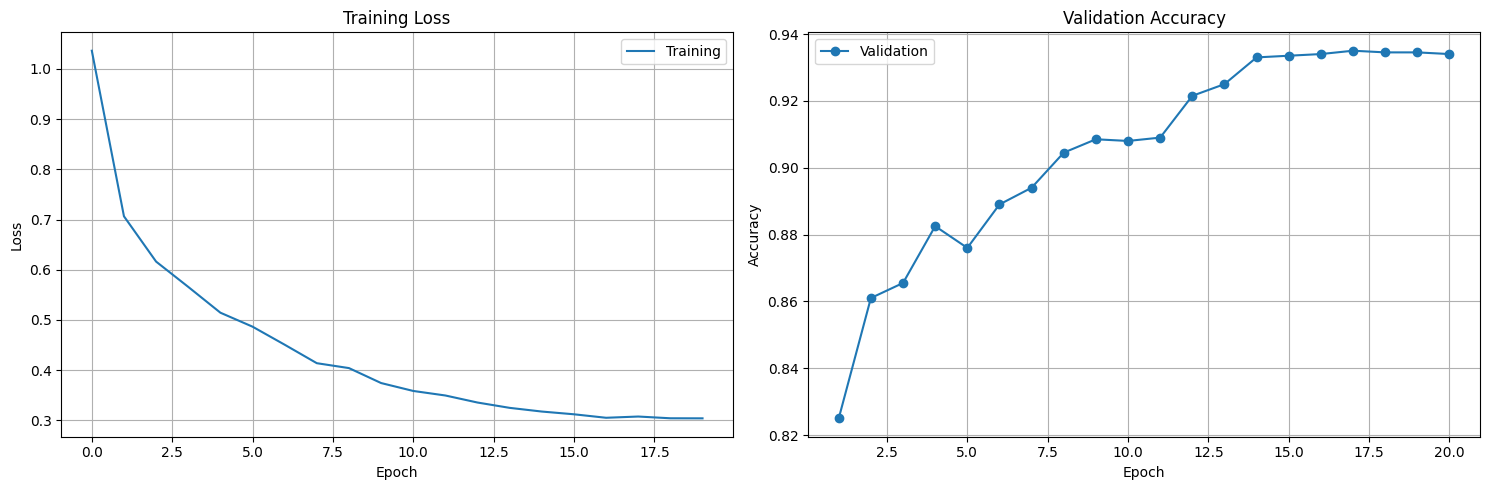

Learning curves saved to generated_data/current_results/training_curves.png


In [21]:
# Plot training curves (skip if validation was skipped)
if not skip_validation and len(train_losses) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot losses
    axes[0].set_title("Training Loss")
    for i, losses in enumerate(train_losses):
        label = f"Fold {i+1}" if use_cross_validation else "Training"
        axes[0].plot(losses, label=label)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # Plot accuracies
    axes[1].set_title("Validation Accuracy")
    for i, accs in enumerate(val_accuracies):
        epochs = [val_frequency * (j+1) for j in range(len(accs))]
        if epochs[-1] != num_epochs:
            epochs.append(num_epochs)
            accs = accs + [accs[-1]]  # Add final epoch if needed
        label = f"Fold {i+1}" if use_cross_validation else "Validation"
        axes[1].plot(epochs, accs, marker='o', label=label)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig("generated_data/current_results/training_curves.png", dpi=150)
    plt.show()

    print("Learning curves saved to generated_data/current_results/training_curves.png")
else:
    print("Skipping plot generation (validation was skipped)")


## Train Final Model on All Data


## (Optional) Move Current Results to Best/Past Folders

After training, if your current model performs better than the best model, you can move files:

- `generated_data/current_results/` → `generated_data/` (best model/submission)
- Old best → `generated_data/models_experimented/` or `generated_data/past_submissions/`

Run this cell manually when you want to promote current results to best.


In [ ]:
# ============================================================
# Final Training on ALL Training Images
# ============================================================

print("\n" + "="*60)
print("Training FINAL model on all training images")
print("="*60 + "\n")

# Use all training data
print("[DEBUG] Creating DataLoader...")
# Windows workaround: disable persistent_workers to avoid pin_memory conflicts
full_train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=False,  # Disabled for Windows compatibility
    prefetch_factor=prefetch_factor
)
print(f"[DEBUG] DataLoader created. Length: {len(full_train_loader)} batches")

# Create model
print("[DEBUG] Creating model...")
if model_name == "efficientnet_b0":
    final_model = create_efficientnet_b0(num_classes=10).to(device)
    final_model = final_model.to(memory_format=torch.channels_last)
elif model_name == "efficientnet_b3":
    final_model = create_efficientnet_b3(num_classes=10).to(device)
    final_model = final_model.to(memory_format=torch.channels_last)
else:
    raise ValueError(f"Unknown model: {model_name}")

# Load best weights from validation if available
if not skip_validation and best_validation_state is not None:
    print("[DEBUG] Loading best weights from validation training...")
    final_model.load_state_dict(best_validation_state)
    print(f"[DEBUG] Best validation weights loaded (acc: {best_overall_acc:.4f}) - continuing training from checkpoint")
else:
    print("[DEBUG] Starting from scratch (no validation weights available)")

print("[DEBUG] Model created and moved to device")

# Optimizer
print("[DEBUG] Creating optimizer...")
final_optimizer = create_optimizer(final_model, learning_rate, weight_decay, optimizer_type)
print(f"[DEBUG] Optimizer created: {optimizer_type}")

# Update scheduler_params for OneCycleLR if needed
if scheduler_type == "OneCycleLR":
    print("[DEBUG] Updating scheduler_params for OneCycleLR...")
    scheduler_params = scheduler_params.copy()
    scheduler_params["steps_per_epoch"] = len(full_train_loader)
    print(f"[DEBUG] steps_per_epoch set to: {scheduler_params['steps_per_epoch']}")

# Scheduler
print(f"[DEBUG] Creating scheduler: {scheduler_type}...")
final_scheduler = create_scheduler(final_optimizer, scheduler_type, scheduler_params)
print("[DEBUG] Scheduler created")

# Loss and scaler
print("[DEBUG] Creating criterion and scaler...")
final_criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
final_scaler = amp.GradScaler("cuda") if use_amp else None
print(f"[DEBUG] Criterion created, AMP: {use_amp}")

# Training loop
print(f"[DEBUG] Starting training loop for {num_epochs} epochs...")
final_losses = []

for epoch in range(num_epochs):
    print(f"[DEBUG] Starting epoch {epoch+1}/{num_epochs}...")
    avg_loss, train_acc = train_one_epoch(
        final_model, full_train_loader, final_criterion, 
        final_optimizer, final_scheduler, final_scaler, use_amp, device
    )
    print(f"[DEBUG] Epoch {epoch+1}/{num_epochs} completed. Loss: {avg_loss:.4f}, Acc: {train_acc:.4f}")
    final_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} | Loss = {avg_loss:.4f} | Acc = {train_acc:.4f}")

# Save final model
model_path = "generated_data/current_results/task2_model.pth"
torch.save(final_model.state_dict(), model_path)
print(f"\nFinal model saved to {model_path}")

# Save training info
training_info = {
    "timestamp": datetime.now().isoformat(),
    "hyperparameters": {
        "num_epochs": num_epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "optimizer": optimizer_type,
        "scheduler": scheduler_type,
        "label_smoothing": label_smoothing,
        "model": model_name,
        "image_size": image_size,
    },
    "cross_validation": {
        "used": use_cross_validation,
        "folds": cv_folds if use_cross_validation else None,
        "fold_results": fold_results if use_cross_validation else None,
        "mean_acc": float(np.mean(fold_results)) if use_cross_validation else None,
    },
    "final_training": {
        "final_losses": final_losses,
        "final_epoch_loss": float(final_losses[-1]),
    }
}

info_path = "generated_data/current_results/training_info.json"
with open(info_path, "w") as f:
    json.dump(training_info, f, indent=4)

print(f"Training info saved to {info_path}")



Training FINAL model on all training images

[DEBUG] Creating DataLoader...
[DEBUG] DataLoader created. Length: 79 batches
[DEBUG] Creating model...
[DEBUG] Loading best weights from validation training...
[DEBUG] Best validation weights loaded (acc: 0.9350) - continuing training from checkpoint
[DEBUG] Model created and moved to device
[DEBUG] Creating optimizer...
[DEBUG] Optimizer created: Adam
[DEBUG] Creating scheduler: CosineAnnealing...
[DEBUG] Scheduler created
[DEBUG] Creating criterion and scaler...
[DEBUG] Criterion created, AMP: True
[DEBUG] Starting training loop for 20 epochs...
[DEBUG] Starting epoch 1/20...
[DEBUG train_one_epoch] Starting epoch. Total batches: 79
[DEBUG train_one_epoch] Loading first batch...
[DEBUG train_one_epoch] First batch loaded to device. Shape: torch.Size([128, 3, 300, 300])
[DEBUG train_one_epoch] First batch forward/backward completed. Loss: 0.3301
[DEBUG train_one_epoch] Processing batch 10/79...
[DEBUG train_one_epoch] Processing batch 20/